<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/Copy_of_Inclass_05_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN Day 1 Housing Data

### Importing Libraries

In [49]:
import pandas as pd                                 # table/dataframe handling
import numpy as np                                  # numerical operations
import matplotlib.pyplot as plt                     # plotting

from sklearn.preprocessing import MinMaxScaler      # scales values to 0-1 range
from sklearn.metrics import mean_absolute_error, mean_squared_error
                                                    # RMSE and MAE calculation

import tensorflow as tf
import random

from tensorflow.keras.models import Sequential      # sequential neural network API

from tensorflow.keras.layers import (
    Dense,                                          # standard fully connected layer
    SimpleRNN,                                      # recurrent neural network layer
    Conv1D,                                         # 1D convolution layer
    Flatten                                         # flatten multidimensional output
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Loading the data

In [50]:
# Uploading dataset into Colab
from google.colab import files
uploaded = files.upload()

Saving ma_lga_12345.csv to ma_lga_12345 (1).csv


In [51]:
# Loading the dataset
import pandas as pd
house = pd.read_csv("ma_lga_12345.csv")
house.head()

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


### Inspecting the temporal nature of the data

In [52]:
print(house.shape)            # number of rows and columns
print(house.dtypes)           # variable data types
print(house.isna().sum())     # missing values per column

house.describe()              # summary statistics

(347, 4)
saledate    object
MA           int64
type        object
bedrooms     int64
dtype: object
saledate    0
MA          0
type        0
bedrooms    0
dtype: int64


,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


## Defining useful functions


Formatting data for rolling windows

In [53]:
def create_sequences(dataset, look_back=2):

    X, y = [], []                          # containers for windows and targets

    for i in range(len(dataset) - look_back):

        X.append(dataset[i:i + look_back, :])   # rolling window
        y.append(dataset[i + look_back, 0])     # next timestep target

    return np.array(X), np.array(y)

Plotting training curves

In [54]:
def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].set_ylim(0, 0.4)
    axes[0].legend()

    axes[1].plot(history.history["mean_absolute_error"], label="Training MAE")
    axes[1].plot(history.history["val_mean_absolute_error"], label="Validation MAE")
    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].set_ylim(0, 0.65)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Evaluating model performance on test data

In [55]:
def evaluate_and_plot(model, trainX, testX, trainY, testY, scaler, title):

    # Make predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Convert scaled values back to original MA scale
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    # Calculate RMSE on original scale
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    # Plot held-out future test predictions
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")

    plt.title(title + " Test Predictions")
    plt.xlabel("Test time index")
    plt.ylabel("MA")
    plt.ylim(0, 1200000)
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.show()

Comparing forcasting performance metrics

In [56]:

def evaluate_metrics(model, testX, testY, scaler):

    test_pred = model.predict(testX)

    test_pred_inv = scaler.inverse_transform(test_pred)
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Initial RNN & Performance

In [57]:
# Initial RNN

ma_sequence = house.copy()
ma_sequence = ma_sequence.sort_values("saledate").reset_index(drop=True)
                                                                # preserve chronological order

df_initial = ma_sequence[["MA"]].copy()                         # univariate forecasting feature

scaler_initial = MinMaxScaler(feature_range=(0, 1))
scaled_initial = scaler_initial.fit_transform(df_initial)
                                                                # neural networks train better on scaled values

look_back = 2                                                   # use previous 2 timesteps to predict next timestep

train_size = int(len(scaled_initial) * 0.8)

train_initial = scaled_initial[:train_size]                     # earlier historical data
test_initial = scaled_initial[train_size:]                      # held-out future data

trainX_initial, trainY_initial = create_sequences(
    train_initial,
    look_back
)                                                               # rolling training windows

testX_initial, testY_initial = create_sequences(
    test_initial,
    look_back
)                                                               # rolling future test windows

print("trainX shape:", trainX_initial.shape)
print("testX shape:", testX_initial.shape)

initial_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_initial.shape[2])
    ),                                                          # recurrent hidden layer

    Dense(1)                                                    # regression output layer
])

initial_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

initial_history = initial_model.fit(
    trainX_initial,
    trainY_initial,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                                              # preserve temporal order
    verbose=1
)

trainX shape: (275, 2, 1)
testX shape: (68, 2, 1)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1027 - mean_absolute_error: 0.2647 - val_loss: 0.0916 - val_mean_absolute_error: 0.2549
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0868 - mean_absolute_error: 0.2409 - val_loss: 0.0807 - val_mean_absolute_error: 0.2324
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0758 - mean_absolute_error: 0.2230 - val_loss: 0.0740 - val_mean_absolute_error: 0.2187
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0682 - mean_absolute_error: 0.2089 - val_loss: 0.0702 - val_mean_absolute_error: 0.2103
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0633 - mean_absolute_error: 0.1992 - val_loss: 0.0686 - val_mean_absolute_error: 0.2046
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0602 - mean_absolute_error: 0.1938 - val_loss: 0.0682 - val_mean_absolute_error: 0.2039
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0583 - mean_absolute_error: 0.1910 - val_loss: 0.0685 - 

Training curves

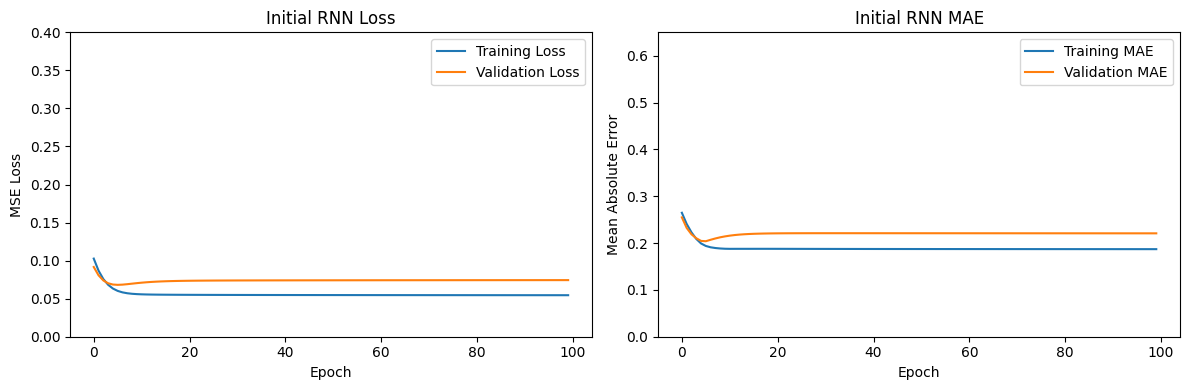

In [58]:
plot_training_curves(
    initial_history,
    "Initial RNN"
)

Test data evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Initial RNN Train RMSE: 168752.01
Initial RNN Test RMSE: 171397.52


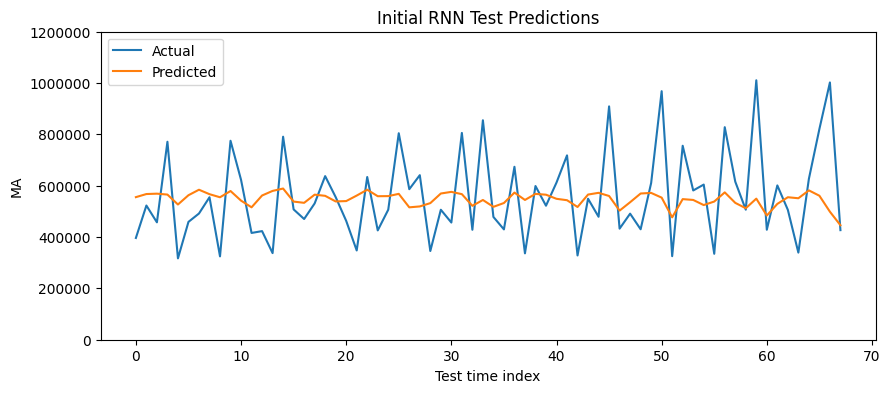

In [59]:
evaluate_and_plot(
    initial_model,
    trainX_initial,
    testX_initial,
    trainY_initial,
    testY_initial,
    scaler_initial,
    "Initial RNN"
)

### Initial MA data re-evaluation

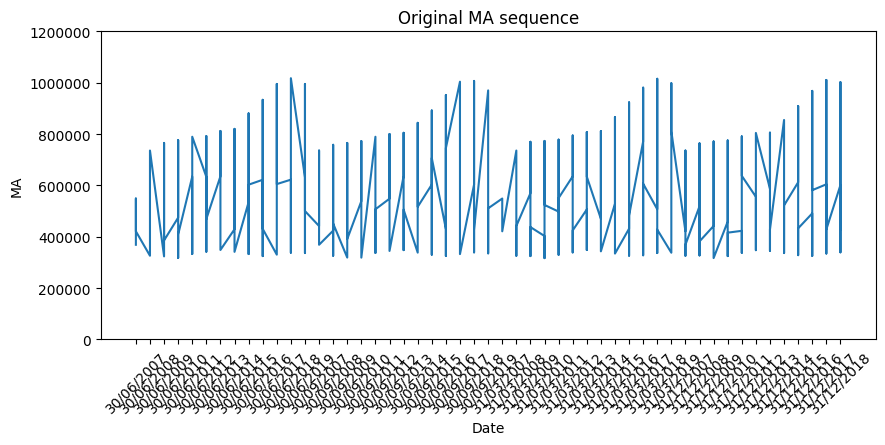

In [60]:
# Plot the original MA sequence exactly as provided

plt.figure(figsize=(10, 4))

plt.plot(
    ma_sequence["saledate"],
    ma_sequence["MA"]
)

plt.title("Original MA sequence")
plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.show()


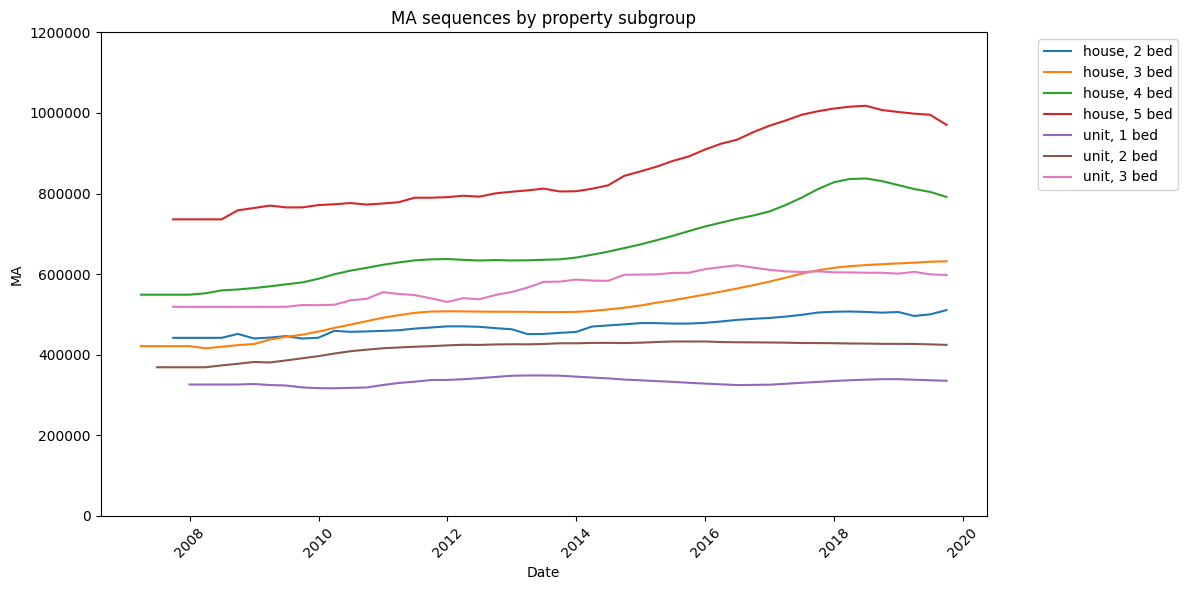

In [61]:
# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

plt.figure(figsize=(12, 6))

for (property_type, bedrooms), group in house.groupby(["type", "bedrooms"]):

    group = group.sort_values("saledate")      # chronological ordering

    plt.plot(
        group["saledate"],
        group["MA"],
        label=f"{property_type}, {bedrooms} bed"
    )

plt.title("MA sequences by property subgroup")

plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Inspecting the first window

In [62]:
print("trainX_initial shape:", trainX_initial.shape)

window_id = 0

ma_sequence.iloc[
    window_id : window_id + look_back + 1
][["saledate", "type", "bedrooms", "MA"]]

trainX_initial shape: (275, 2, 1)


,saledate,type,bedrooms,MA
0,30/06/2007,unit,2,368817
1,30/06/2007,house,4,548969
2,30/06/2007,house,3,421291


### Creating market-level MA data

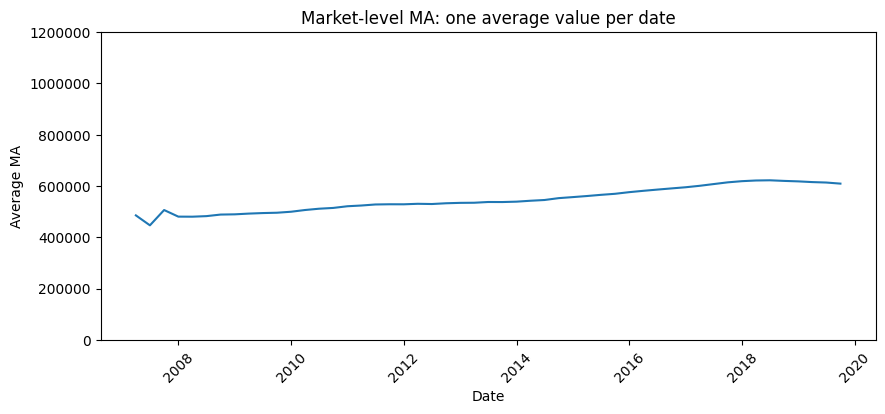

In [63]:
# Create market-level MA sequence

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)                                                    # ensure dates sort chronologically

market_ma = (
    house
    .groupby("saledate")["MA"]
    .mean()
    .reset_index()
    .sort_values("saledate")
    .reset_index(drop=True)
)                                                    # average subgroup MAs per date

# Visualize market-level MA

plt.figure(figsize=(10, 4))

plt.plot(
    market_ma["saledate"],
    market_ma["MA"]
)

plt.title("Market-level MA: one average value per date")
plt.xlabel("Date")
plt.ylabel("Average MA")

plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.show()

### Preparing market-level MA data for variety of models

In [64]:
# Prepare market-level MA data for all fixed-data models

df_market = market_ma[["MA"]].copy()                            # cleaned one-value-per-date MA series

scaler_market = MinMaxScaler(feature_range=(0, 1))              # scale MA values for neural networks
scaled_market = scaler_market.fit_transform(df_market)

look_back = 2                                                   # use 2 previous timesteps to predict next timestep

train_size = int(len(scaled_market) * 0.8)                      # chronological 80/20 split

train_market = scaled_market[:train_size]                       # earlier historical data
test_market = scaled_market[train_size:]                        # held-out future data

trainX_market, trainY_market = create_sequences(
    train_market,
    look_back
)                                                               # sequence windows for RNN/CNN

testX_market, testY_market = create_sequences(
    test_market,
    look_back
)                                                               # future test windows for RNN/CNN

trainX_market_mlp = trainX_market.reshape(
    trainX_market.shape[0],
    trainX_market.shape[1] * trainX_market.shape[2]
)                                                               # flattened windows for MLP

testX_market_mlp = testX_market.reshape(
    testX_market.shape[0],
    testX_market.shape[1] * testX_market.shape[2]
)                                                               # flattened test windows for MLP

print("RNN/CNN trainX_market shape:", trainX_market.shape)
print("RNN/CNN testX_market shape:", testX_market.shape)

print("MLP trainX_market_mlp shape:", trainX_market_mlp.shape)
print("MLP testX_market_mlp shape:", testX_market_mlp.shape)

RNN/CNN trainX_market shape: (38, 2, 1)
RNN/CNN testX_market shape: (9, 2, 1)
MLP trainX_market_mlp shape: (38, 2)
MLP testX_market_mlp shape: (9, 2)


### Inspecting the tensors

Shape & window 0 values

In [65]:
print("trainX_market shape:", trainX_market.shape)

window_id = 0

market_ma.iloc[
    window_id : window_id + look_back + 1
][["saledate", "MA"]]

trainX_market shape: (38, 2, 1)


,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667


Scale window 0

In [66]:
# Visualize one input window and its target

window_id = 0

print("Input window:")
print(trainX_market[window_id].flatten())

print("Target:")
print(trainY_market[window_id])

Input window:
[0.22095731 0.        ]
Target:
0.33965492068299463


### Market-level RNN model & evaluation

In [67]:
# Build and train market-level RNN model

market_rnn_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_market.shape[2])
    ),
    Dense(1)
])

market_rnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_rnn_history = market_rnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0500 - mean_absolute_error: 0.2169 - val_loss: 0.1204 - val_mean_absolute_error: 0.3453
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0223 - mean_absolute_error: 0.1427 - val_loss: 0.0597 - val_mean_absolute_error: 0.2425
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0068 - mean_absolute_error: 0.0768 - val_loss: 0.0229 - val_mean_absolute_error: 0.1492
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0017 - mean_absolute_error: 0.0272 - val_loss: 0.0061 - val_mean_absolute_error: 0.0754
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0028 - mean_absolute_error: 0.0423 - val_loss: 0.0013 - val_mean_absolute_error: 0.0306
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0049 - mean_absolute_error: 0.0608 - val_loss: 6.6129e-04 - val_mean_absolute_error: 0.0215
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0052 - mean_absolute_error: 0.0612 - val_loss: 0.0013 - val

Training curves

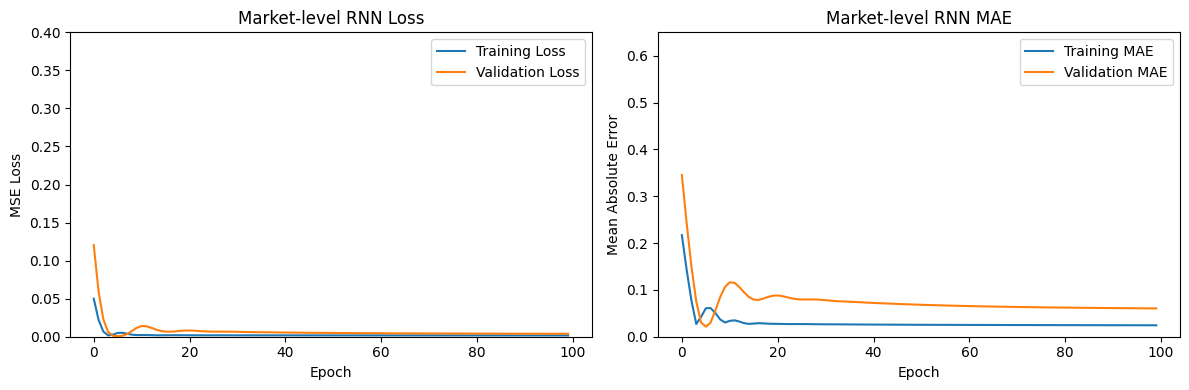

In [68]:
plot_training_curves(
    market_rnn_history,
    "Market-level RNN"
)

Test data evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Market-level RNN Train RMSE: 8131.16
Market-level RNN Test RMSE: 15985.00


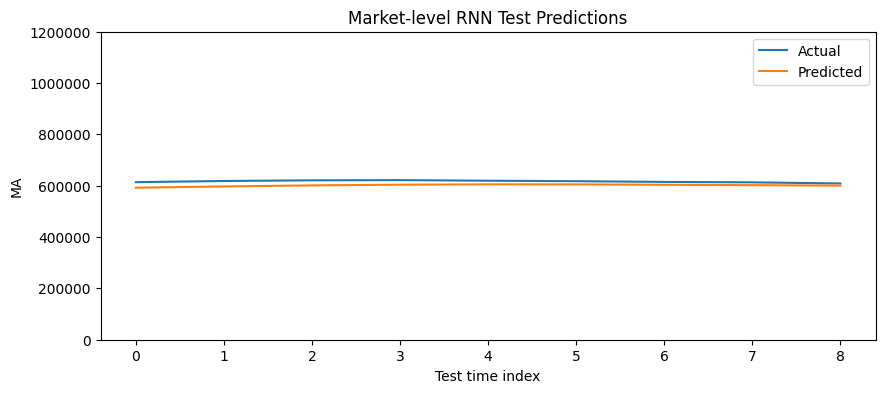

In [69]:
evaluate_and_plot(
    market_rnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level RNN"
)

### Market level MLP and evaluation

In [70]:
# Build and train market-level MLP model

market_mlp_model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(trainX_market_mlp.shape[1],)
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(1)
])

market_mlp_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_mlp_history = market_mlp_model.fit(
    trainX_market_mlp,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0963 - mean_absolute_error: 0.2989 - val_loss: 0.2720 - val_mean_absolute_error: 0.5195
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0762 - mean_absolute_error: 0.2646 - val_loss: 0.2254 - val_mean_absolute_error: 0.4728
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0604 - mean_absolute_error: 0.2341 - val_loss: 0.1870 - val_mean_absolute_error: 0.4305
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0456 - mean_absolute_error: 0.2016 - val_loss: 0.1498 - val_mean_absolute_error: 0.3851
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0322 - mean_absolute_error: 0.1670 - val_loss: 0.1146 - val_mean_absolute_error: 0.3366
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0213 - mean_absolute_error: 0.1330 - val_loss: 0.0845 - val_mean_absolute_error: 0.2888
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0130 - mean_absolute_error: 0.1011 - val_loss: 0.0601 - val_mean

Training curves MLP

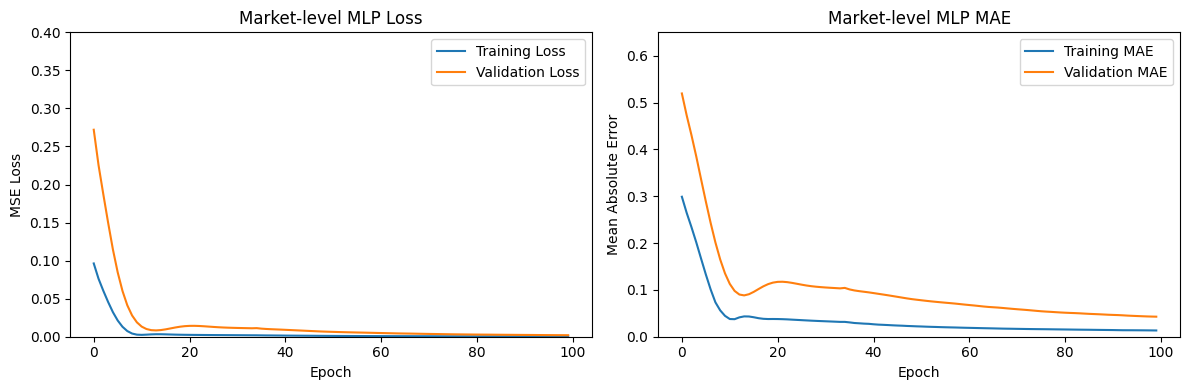

In [71]:
plot_training_curves(
    market_mlp_history,
    "Market-level MLP"
)

Test data evaluation MLP

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Market-level MLP Train RMSE: 4631.41
Market-level MLP Test RMSE: 10526.73


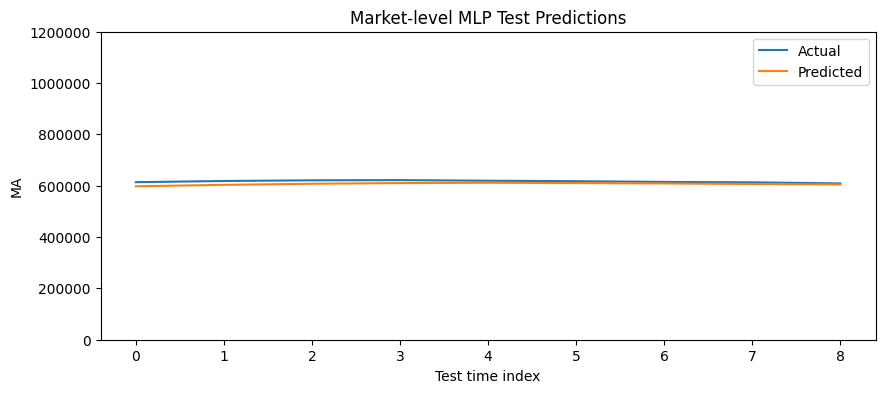

In [72]:
evaluate_and_plot(
    market_mlp_model,
    trainX_market_mlp,
    testX_market_mlp,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level MLP"
)

### Market level CNN & evaluation

In [73]:
# Build and train market-level 1D CNN model

market_cnn_model = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation="relu",
        input_shape=(look_back, trainX_market.shape[2])
    ),                                      # input shape = timesteps, features

    Flatten(),                              # convert CNN output to flat vector for Dense layer

    Dense(1)                                # regression output layer
])

market_cnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_cnn_history = market_cnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0999 - mean_absolute_error: 0.3029 - val_loss: 0.2975 - val_mean_absolute_error: 0.5433
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0884 - mean_absolute_error: 0.2840 - val_loss: 0.2710 - val_mean_absolute_error: 0.5184
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0778 - mean_absolute_error: 0.2656 - val_loss: 0.2458 - val_mean_absolute_error: 0.4937
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0681 - mean_absolute_error: 0.2474 - val_loss: 0.2222 - val_mean_absolute_error: 0.4693
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0592 - mean_absolute_error: 0.2297 - val_loss: 0.2003 - val_mean_absolute_error: 0.4455
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0514 - mean_absolute_error: 0.2127 - val_loss: 0.1801 - val_mean_absolute_error: 0.4224
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0445 - mean_absolute_error: 0.1967 - val_loss: 0.1618 - val_mean

Training curves 1D CNN

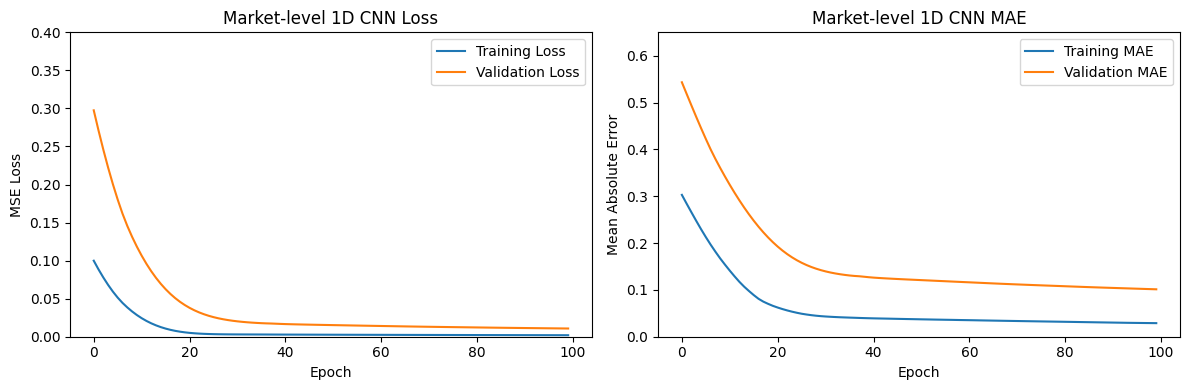

In [74]:
plot_training_curves(
    market_cnn_history,
    "Market-level 1D CNN"
)

Test data evaluation 1D CNN

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Market-level 1D CNN Train RMSE: 10858.95
Market-level 1D CNN Test RMSE: 27010.29


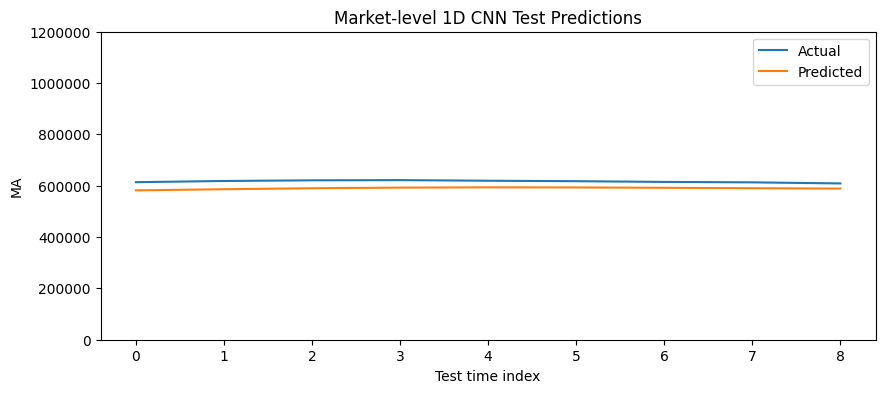

In [75]:
evaluate_and_plot(
    market_cnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level 1D CNN"
)

### Comparison of RNN vs MLP vs 1D CNN

In [76]:
rnn_rmse, rnn_mae = evaluate_metrics(
    market_rnn_model,
    testX_market,
    testY_market,
    scaler_market
)

mlp_rmse, mlp_mae = evaluate_metrics(
    market_mlp_model,
    testX_market_mlp,
    testY_market,
    scaler_market
)

cnn_rmse, cnn_mae = evaluate_metrics(
    market_cnn_model,
    testX_market,
    testY_market,
    scaler_market
)

comparison = pd.DataFrame({
    "Model": ["RNN", "MLP", "1D CNN"],
    "RMSE": [rnn_rmse, mlp_rmse, cnn_rmse],
    "MAE": [rnn_mae, mlp_mae, cnn_mae]
})

comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


,Model,RMSE,MAE
0,RNN,15985.004700,15295.120040
1,MLP,10526.726267,9675.571429
2,1D CNN,27010.286225,26676.696429


### Your Turn — Build and Compare RNN Models

Choose one or more coherent housing subgroups (for example, 3-bedroom houses) and build at least 3 meaningfully different RNN forecasting models. Evaluate each model using training/validation curves, held-out future test predictions, RMSE, and MAE, and record your observations in markdown cells throughout the notebook.

### Model Exploration Summary

Briefly summarize which subgroup(s) and model variations you explored, what changes appeared to improve or worsen forecasting performance, any patterns you noticed in the training curves or predictions, and which model you believe performed best and why.

In [80]:
# Choosing one coherent subgroup: 3-bedroom houses

house["saledate"] = pd.to_datetime(house["saledate"], dayfirst=True)

subgroup_ma = (
    house[(house["type"] == "house") & (house["bedrooms"] == 3)]
    .sort_values("saledate")
    .reset_index(drop=True)
)

subgroup_ma.head()

,saledate,MA,type,bedrooms
0,2007-03-31,421291,house,3
1,2007-06-30,421291,house,3
2,2007-09-30,421291,house,3
3,2007-12-31,421291,house,3
4,2008-03-31,416031,house,3


In [81]:
print(subgroup_ma.shape)
print(subgroup_ma[["saledate", "type", "bedrooms", "MA"]].head())
print(subgroup_ma[["saledate", "type", "bedrooms", "MA"]].tail())

(51, 4)
    saledate   type  bedrooms      MA
0 2007-03-31  house         3  421291
1 2007-06-30  house         3  421291
2 2007-09-30  house         3  421291
3 2007-12-31  house         3  421291
4 2008-03-31  house         3  416031
     saledate   type  bedrooms      MA
46 2018-09-30  house         3  624602
47 2018-12-31  house         3  626608
48 2019-03-31  house         3  628423
49 2019-06-30  house         3  630814
50 2019-09-30  house         3  631875


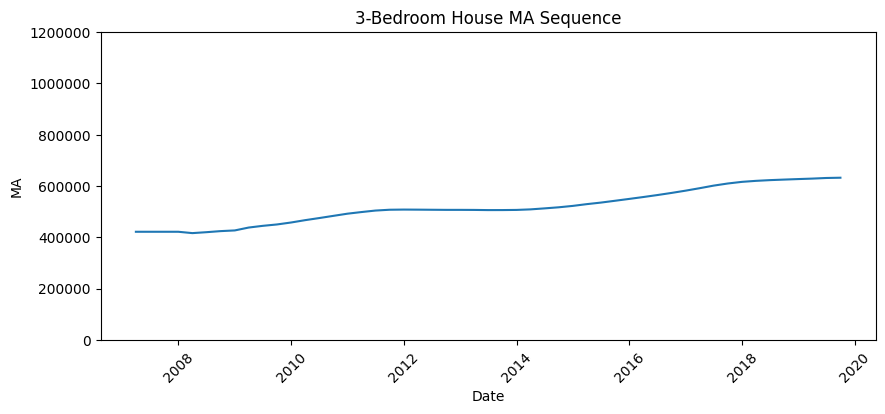

In [82]:
plt.figure(figsize=(10, 4))

plt.plot(
    subgroup_ma["saledate"],
    subgroup_ma["MA"]
)

plt.title("3-Bedroom House MA Sequence")
plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.show()

In [83]:
# Preparing subgroup MA sequence for RNN models

df_subgroup = subgroup_ma[["MA"]].copy()

scaler_subgroup = MinMaxScaler(feature_range=(0, 1))

scaled_subgroup = scaler_subgroup.fit_transform(df_subgroup)

look_back = 4

train_size = int(len(scaled_subgroup) * 0.8)

train_subgroup = scaled_subgroup[:train_size]
test_subgroup = scaled_subgroup[train_size:]

trainX_subgroup, trainY_subgroup = create_sequences(
    train_subgroup,
    look_back
)

testX_subgroup, testY_subgroup = create_sequences(
    test_subgroup,
    look_back
)

print("trainX_subgroup shape:", trainX_subgroup.shape)
print("testX_subgroup shape:", testX_subgroup.shape)

trainX_subgroup shape: (36, 4, 1)
testX_subgroup shape: (7, 4, 1)


In [84]:
# Model 1: Baseline RNN for 3-bedroom houses

subgroup_rnn_model_1 = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_subgroup.shape[2])
    ),
    Dense(1)
])

subgroup_rnn_model_1.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

subgroup_rnn_history_1 = subgroup_rnn_model_1.fit(
    trainX_subgroup,
    trainY_subgroup,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0013 - mean_absolute_error: 0.0309 - val_loss: 0.0015 - val_mean_absolute_error: 0.0315
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0025 - mean_absolute_error: 0.0427 - val_loss: 0.0018 - val_mean_absolute_error: 0.0358
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4.9939e-04 - mean_absolute_error: 0.0170 - val_loss: 0.0101 - val_mean_absolute_error: 0.0968
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.4005e-04 - mean_absolute_error: 0.0276 - val_loss: 0.0101 - val_mean_absolute_error: 0.0970
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.7083e-04 - mean_absolute_error: 0.0152 - val_loss: 0.0043 - val_mean_absolute_error: 0.0604
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 6.1515e-04 - mean_absolute_error: 0.0194 - val_loss: 0.0027 - val_mean_absolute_error: 0.0457
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.5338e-04 - mean_absolute_error: 0.0186 - val_lo

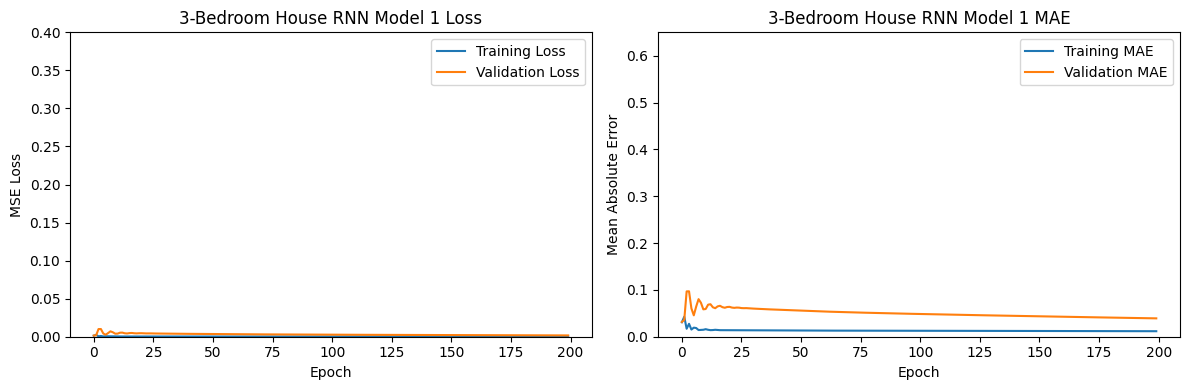

In [85]:
plot_training_curves(
    subgroup_rnn_history_1,
    "3-Bedroom House RNN Model 1"
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
3-Bedroom House RNN Model 1 Train RMSE: 4964.47
3-Bedroom House RNN Model 1 Test RMSE: 17097.13


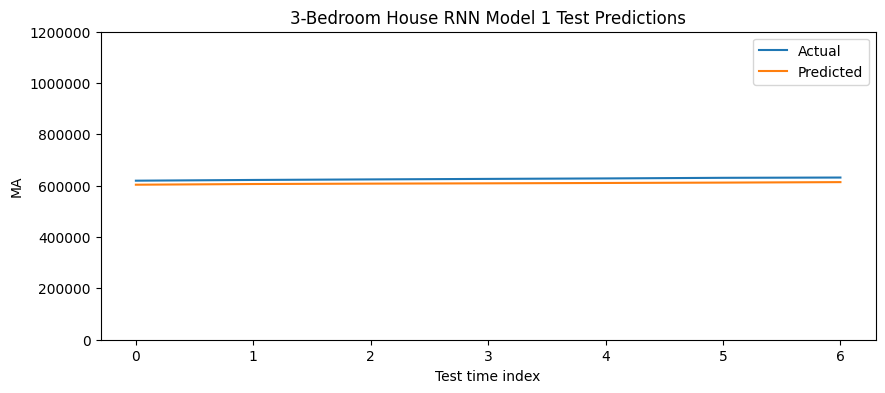

In [86]:
evaluate_and_plot(
    subgroup_rnn_model_1,
    trainX_subgroup,
    testX_subgroup,
    trainY_subgroup,
    testY_subgroup,
    scaler_subgroup,
    "3-Bedroom House RNN Model 1"
)

Model 1 served as the baseline RNN for the 3-bedroom house MA sequence. The model used a single SimpleRNN layer containing 16 hidden units and a look-back window of 4 timesteps.

The training and validation loss curves remained relatively stable throughout training. The validation MAE remained consistently higher than the training MAE.

Overall, Model 1 provided a strong baseline and demonstrated that a simple recurrent architecture can forecast the relatively smooth 3-bedroom housing sequence with reasonable accuracy.

In [95]:
# Model 2: Larger RNN with longer look-back window

look_back_2 = 10

trainX_subgroup_2, trainY_subgroup_2 = create_sequences(
    train_subgroup,
    look_back_2
)

testX_subgroup_2, testY_subgroup_2 = create_sequences(
    test_subgroup,
    look_back_2
)

print("trainX_subgroup_2 shape:", trainX_subgroup_2.shape)
print("testX_subgroup_2 shape:", testX_subgroup_2.shape)

trainX_subgroup_2 shape: (30, 10, 1)
testX_subgroup_2 shape: (1, 10, 1)


In [96]:
subgroup_rnn_model_2 = Sequential([
    SimpleRNN(
        32,
        activation="tanh",
        input_shape=(look_back_2, trainX_subgroup_2.shape[2])
    ),
    Dense(1)
])

subgroup_rnn_model_2.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

subgroup_rnn_history_2 = subgroup_rnn_model_2.fit(
    trainX_subgroup_2,
    trainY_subgroup_2,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - loss: 0.0793 - mean_absolute_error: 0.2627 - val_loss: 0.0736 - val_mean_absolute_error: 0.2640
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0200 - mean_absolute_error: 0.1231 - val_loss: 0.0035 - val_mean_absolute_error: 0.0498
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0276 - mean_absolute_error: 0.1427 - val_loss: 0.0034 - val_mean_absolute_error: 0.0493
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0175 - mean_absolute_error: 0.1111 - val_loss: 0.0059 - val_mean_absolute_error: 0.0630
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0046 - mean_absolute_error: 0.0592 - val_loss: 0.0283 - val_mean_absolute_error: 0.1600
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0044 - mean_absolute_error: 0.0537 - val_loss: 0.0562 - val_mean_absolute_error: 0.2313
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0079 - mean_absolute_error: 0.0790 - val_loss: 0.0629 - val_mea

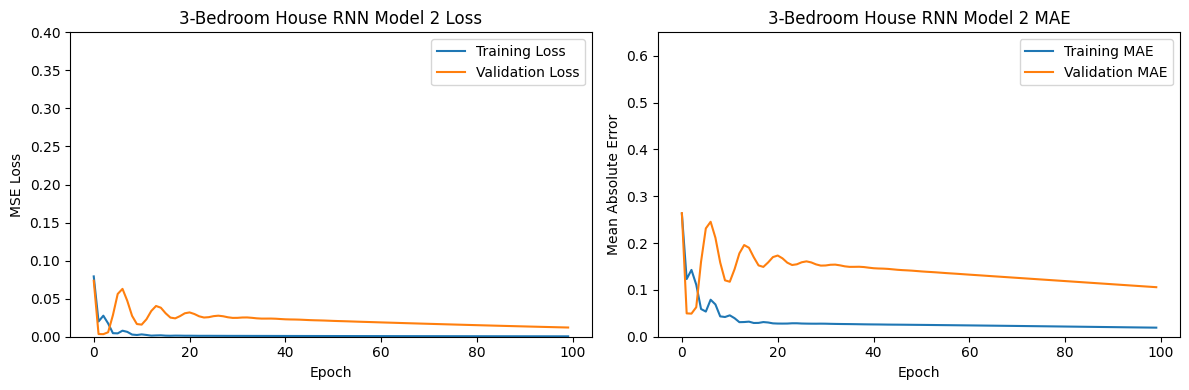

In [97]:
plot_training_curves(
    subgroup_rnn_history_2,
    "3-Bedroom House RNN Model 2"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
3-Bedroom House RNN Model 2 Train RMSE: 11431.52
3-Bedroom House RNN Model 2 Test RMSE: 58321.88


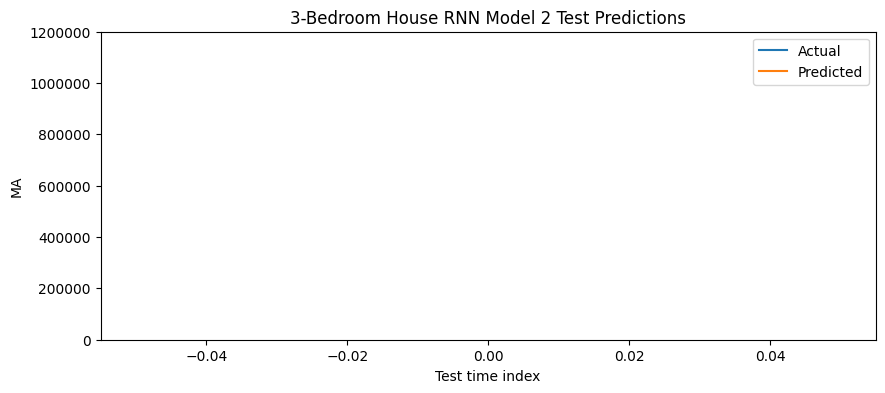

In [98]:
evaluate_and_plot(
    subgroup_rnn_model_2,
    trainX_subgroup_2,
    testX_subgroup_2,
    trainY_subgroup_2,
    testY_subgroup_2,
    scaler_subgroup,
    "3-Bedroom House RNN Model 2"
)

Model 2 increased the complexity of the baseline RNN by using 32 hidden units and a much longer look-back window of 10 timesteps. I wanted to determine whether giving the model more historical context would improve forecasting performance.

However, Model 2 performed substantially worse than Model 1. The test RMSE increased from approximately 17,097 to 58,322, indicating that the larger model generalized poorly to future observations.

The training loss remained very low, while the validation loss and validation MAE stayed higher throughout training. This suggests that the model overfit the relatively small subgroup dataset. Increasing the look-back window also reduced the number of available training windows, which may have limited the model's ability to generalize effectively.

The held-out predictions appeared less accurate compared to Model 1. Increasing both the model size and the look-back window significantly worsened forecasting performance for this subgroup.

In [105]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
# Model 3: Deeper stacked RNN with dropout and early stopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)



subgroup_rnn_model_3 = Sequential([
    SimpleRNN(
        32,
        activation="relu",
        return_sequences=True,
        input_shape=(look_back_2, trainX_subgroup_2.shape[2])
    ),
    Dropout(0.2),

    SimpleRNN(
        8,
        activation="relu"
    ),
    Dropout(0.2),

    Dense(1)
])

subgroup_rnn_model_3.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

subgroup_rnn_history_3 = subgroup_rnn_model_3.fit(
    trainX_subgroup_2,
    trainY_subgroup_2,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - loss: 0.0681 - mean_absolute_error: 0.2477 - val_loss: 0.1404 - val_mean_absolute_error: 0.3729
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0563 - mean_absolute_error: 0.2093 - val_loss: 0.0989 - val_mean_absolute_error: 0.3127
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0572 - mean_absolute_error: 0.2027 - val_loss: 0.0627 - val_mean_absolute_error: 0.2486
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0270 - mean_absolute_error: 0.1323 - val_loss: 0.0343 - val_mean_absolute_error: 0.1836
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0217 - mean_absolute_error: 0.1175 - val_loss: 0.0176 - val_mean_absolute_error: 0.1308
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0176 - mean_absolute_error: 0.1066 - val_loss: 0.0116 - val_mean_absolute_error: 0.1057
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0218 - mean_absolute_error: 0.1243 - val_loss: 0.0106 - val_mea

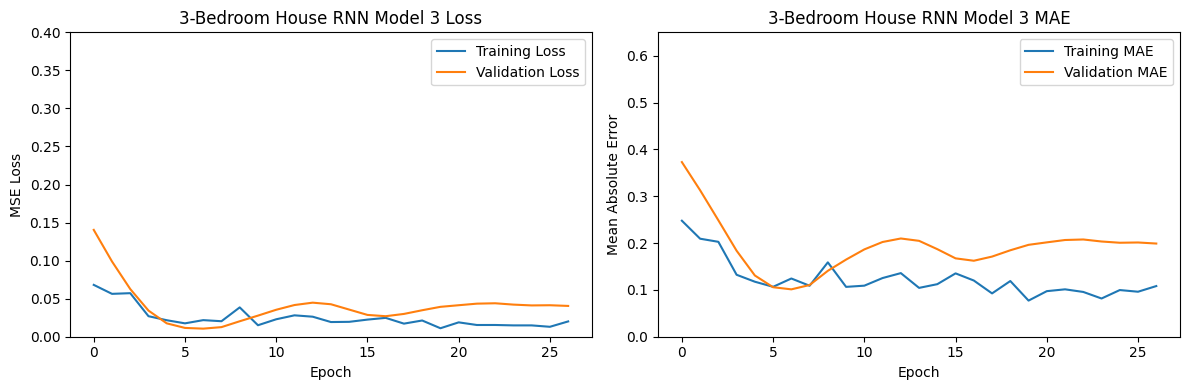

In [106]:
plot_training_curves(
    subgroup_rnn_history_3,
    "3-Bedroom House RNN Model 3"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
3-Bedroom House RNN Model 3 Train RMSE: 11457.10
3-Bedroom House RNN Model 3 Test RMSE: 25243.50


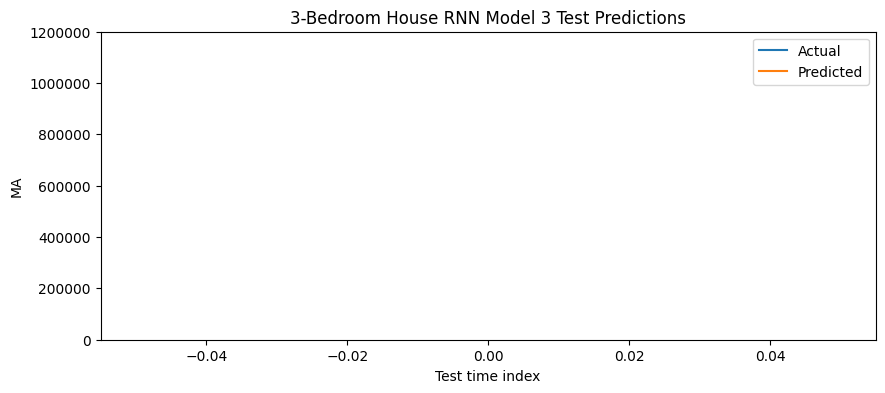

In [107]:
evaluate_and_plot(
    subgroup_rnn_model_3,
    trainX_subgroup_2,
    testX_subgroup_2,
    trainY_subgroup_2,
    testY_subgroup_2,
    scaler_subgroup,
    "3-Bedroom House RNN Model 3"
)

Model 3 tested a deeper stacked RNN architecture with dropout and early stopping. I added a second recurrent layer and dropout regularization, while early stopping was used to stop training once validation loss stopped improving.

This model improved substantially over Model 2. The test RMSE decreased from about 58,322 to about 25,244, suggesting that regularization and early stopping helped reduce some of the overfitting seen in the larger Model 2. The validation curves were less smooth than the training curves, but early stopping prevented the model from continuing too long.

Although Model 3 was better than Model 2, it still did not outperform the simpler baseline Model 1. This suggests that adding depth and regularization helped, but the subgroup sequence may still be too small and smooth for a more complex stacked RNN.

In [108]:
# Evaluating all subgroup RNN models

rnn1_rmse, rnn1_mae = evaluate_metrics(
    subgroup_rnn_model_1,
    testX_subgroup,
    testY_subgroup,
    scaler_subgroup
)

rnn2_rmse, rnn2_mae = evaluate_metrics(
    subgroup_rnn_model_2,
    testX_subgroup_2,
    testY_subgroup_2,
    scaler_subgroup
)

rnn3_rmse, rnn3_mae = evaluate_metrics(
    subgroup_rnn_model_3,
    testX_subgroup_2,
    testY_subgroup_2,
    scaler_subgroup
)

# Comparison table

subgroup_comparison = pd.DataFrame({
    "Model": [
        "RNN Model 1",
        "RNN Model 2",
        "RNN Model 3"
    ],
    "RMSE": [
        rnn1_rmse,
        rnn2_rmse,
        rnn3_rmse
    ],
    "MAE": [
        rnn1_mae,
        rnn2_mae,
        rnn3_mae
    ]
})

subgroup_comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


,Model,RMSE,MAE
0,RNN Model 1,17097.126682,17066.357143
1,RNN Model 2,58321.875000,58321.875000
2,RNN Model 3,25243.500000,25243.500000


In [110]:
from tensorflow.keras.optimizers import Adam
# Model 4: Deeper stacked RNN with longer look-back, dropout, and early stopping

look_back_4 = 6

trainX_subgroup_4, trainY_subgroup_4 = create_sequences(
    train_subgroup,
    look_back_4
)

testX_subgroup_4, testY_subgroup_4 = create_sequences(
    test_subgroup,
    look_back_4
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

subgroup_rnn_model_4 = Sequential([
    SimpleRNN(
        48,
        activation="tanh",
        return_sequences=True,
        input_shape=(look_back_4, trainX_subgroup_4.shape[2])
    ),
    Dropout(0.2),

    SimpleRNN(
        24,
        activation="tanh"
    ),
    Dropout(0.2),

    Dense(1)
])

subgroup_rnn_model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

subgroup_rnn_history_4 = subgroup_rnn_model_4.fit(
    trainX_subgroup_4,
    trainY_subgroup_4,
    epochs=250,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - loss: 0.1433 - mean_absolute_error: 0.2836 - val_loss: 0.0055 - val_mean_absolute_error: 0.0633
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0498 - mean_absolute_error: 0.1555 - val_loss: 0.0011 - val_mean_absolute_error: 0.0285
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0543 - mean_absolute_error: 0.1621 - val_loss: 0.0242 - val_mean_absolute_error: 0.1503
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0276 - mean_absolute_error: 0.1205 - val_loss: 0.0536 - val_mean_absolute_error: 0.2272
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0300 - mean_absolute_error: 0.1472 - val_loss: 0.0837 - val_mean_absolute_error: 0.2852
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0326 - mean_absolute_error: 0.1385 - val_loss: 0.0362 - val_mean_absolute_error: 0.1851
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0313 - mean_absolute_error: 0.1458 - val_loss: 0.0021 - val_mea

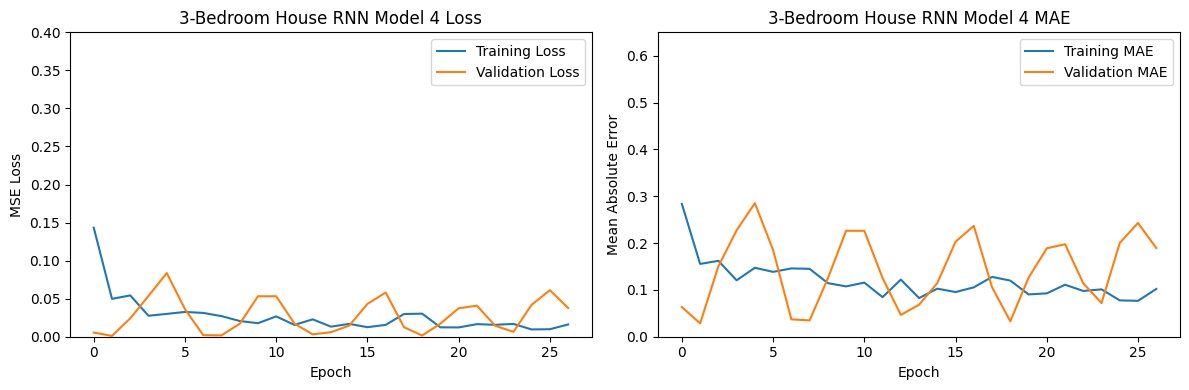

In [111]:
plot_training_curves(
    subgroup_rnn_history_4,
    "3-Bedroom House RNN Model 4"
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
3-Bedroom House RNN Model 4 Train RMSE: 23679.35
3-Bedroom House RNN Model 4 Test RMSE: 18519.91


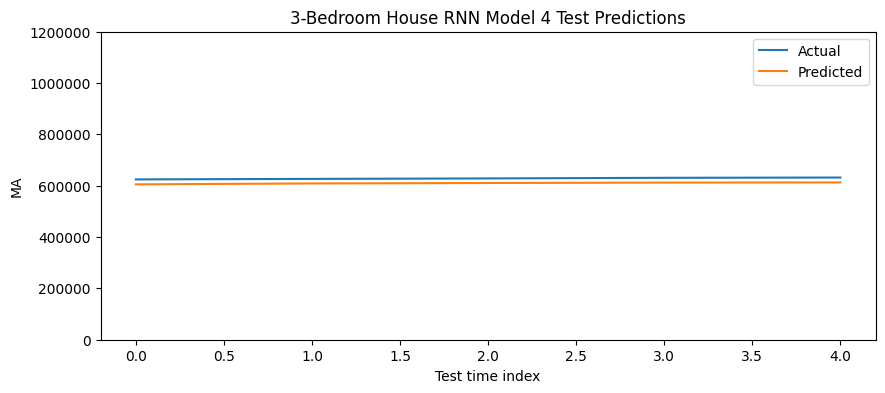

In [112]:
evaluate_and_plot(
    subgroup_rnn_model_4,
    trainX_subgroup_4,
    testX_subgroup_4,
    trainY_subgroup_4,
    testY_subgroup_4,
    scaler_subgroup,
    "3-Bedroom House RNN Model 4"
)

Model 4 used a deeper stacked RNN with a longer look-back window of 6, dropout, early stopping, and a specified Adam learning rate. Compared with Model 3, this model used `tanh` activations instead of `relu`, more hidden units, and a slightly shorter look-back window than Model 2.

Model 4 performed better than Model 2 and Model 3, with a test RMSE of about 18,520. This suggests that the combination of a moderate look-back window, dropout, early stopping, and `tanh` activation improved generalization.

The training and validation curves varied more than Model 1, but early stopping helped prevent the model from training too long.

Overall, Model 4 was one of the stronger models, but it still did not outperform the simpler baseline Model 1 based on RMSE.

In [113]:
rnn4_rmse, rnn4_mae = evaluate_metrics(
    subgroup_rnn_model_4,
    testX_subgroup_4,
    testY_subgroup_4,
    scaler_subgroup
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [114]:
subgroup_comparison = pd.DataFrame({
    "Model": [
        "RNN Model 1",
        "RNN Model 2",
        "RNN Model 3",
        "RNN Model 4"
    ],
    "RMSE": [
        rnn1_rmse,
        rnn2_rmse,
        rnn3_rmse,
        rnn4_rmse
    ],
    "MAE": [
        rnn1_mae,
        rnn2_mae,
        rnn3_mae,
        rnn4_mae
    ]
})

subgroup_comparison

,Model,RMSE,MAE
0,RNN Model 1,17097.126682,17066.357143
1,RNN Model 2,58321.875000,58321.875000
2,RNN Model 3,25243.500000,25243.500000
3,RNN Model 4,18519.906887,18508.400000


In [116]:
from tensorflow.keras.layers import LSTM, Dropout, Dense, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# Model 5: LSTM model with longer look-back, dropout, and early stopping

look_back_5 = 6

trainX_subgroup_5, trainY_subgroup_5 = create_sequences(
    train_subgroup,
    look_back_5
)

testX_subgroup_5, testY_subgroup_5 = create_sequences(
    test_subgroup,
    look_back_5
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

subgroup_rnn_model_5 = Sequential([
    LSTM(
        48,
        activation="tanh",
        input_shape=(look_back_5, trainX_subgroup_5.shape[2])
    ),
    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

subgroup_rnn_model_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

subgroup_rnn_history_5 = subgroup_rnn_model_5.fit(
    trainX_subgroup_5,
    trainY_subgroup_5,
    epochs=250,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.1022 - mean_absolute_error: 0.2989 - val_loss: 0.2935 - val_mean_absolute_error: 0.5383
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0777 - mean_absolute_error: 0.2582 - val_loss: 0.2347 - val_mean_absolute_error: 0.4811
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0542 - mean_absolute_error: 0.2138 - val_loss: 0.1783 - val_mean_absolute_error: 0.4188
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0357 - mean_absolute_error: 0.1716 - val_loss: 0.1151 - val_mean_absolute_error: 0.3357
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0175 - mean_absolute_error: 0.1213 - val_loss: 0.0606 - val_mean_absolute_error: 0.2423
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0059 - mean_absolute_error: 0.0615 - val_loss: 0.0231 - val_mean_absolute_error: 0.1475
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0057 - mean_absolute_error: 0.0575 - val_loss: 0.0062 - val_mea

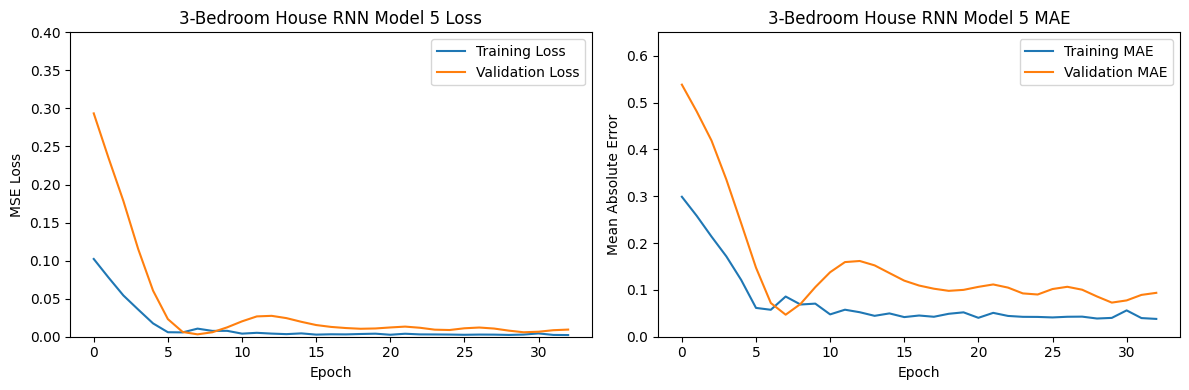

In [117]:
plot_training_curves(
    subgroup_rnn_history_5,
    "3-Bedroom House RNN Model 5"
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
3-Bedroom House RNN Model 5 Train RMSE: 18960.54
3-Bedroom House RNN Model 5 Test RMSE: 21938.50


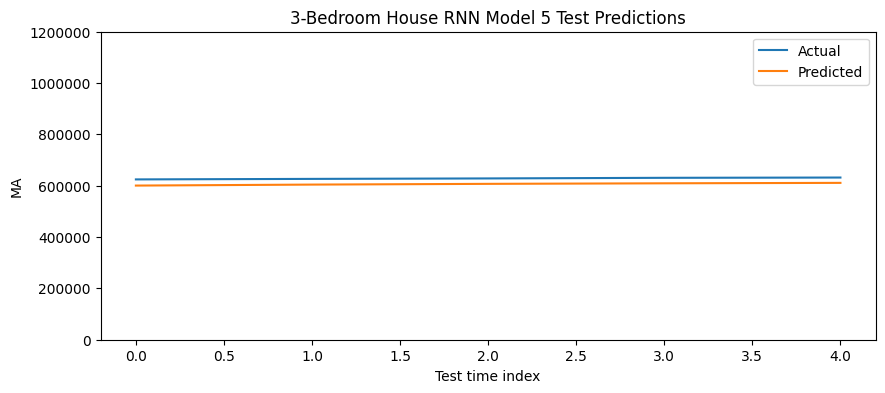

In [118]:
evaluate_and_plot(
    subgroup_rnn_model_5,
    trainX_subgroup_5,
    testX_subgroup_5,
    trainY_subgroup_5,
    testY_subgroup_5,
    scaler_subgroup,
    "3-Bedroom House RNN Model 5"
)

Model 5 replaced the SimpleRNN architecture with an LSTM model. It also used a longer look-back window of 6, dropout, and early stopping.

Model 5 performed better than Model 2 and Model 3, with a test RMSE of about 21,939. However, it did not outperform Model 1 or Model 4. The training and validation curves improved quickly early in training, but the validation MAE remained higher than the training MAE, showing some generalization gap.

The test prediction plot shows that the LSTM produced smooth predictions that followed the overall level of the actual values but slightly underestimated the future MA values. This suggests that the LSTM captured the broad trend, but did not create a perfect result for this subgroup sequence.

The LSTM was useful to test, but the simpler RNN structures performed as well or better for this dataset.

In [119]:
rnn5_rmse, rnn5_mae = evaluate_metrics(
    subgroup_rnn_model_5,
    testX_subgroup_5,
    testY_subgroup_5,
    scaler_subgroup
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [120]:
subgroup_comparison = pd.DataFrame({
    "Model": [
        "RNN Model 1",
        "RNN Model 2",
        "RNN Model 3",
        "RNN Model 4",
        "RNN Model 5"
    ],
    "RMSE": [
        rnn1_rmse,
        rnn2_rmse,
        rnn3_rmse,
        rnn4_rmse,
        rnn5_rmse
    ],
    "MAE": [
        rnn1_mae,
        rnn2_mae,
        rnn3_mae,
        rnn4_mae,
        rnn5_mae
    ]
})

subgroup_comparison

,Model,RMSE,MAE
0,RNN Model 1,17097.126682,17066.357143
1,RNN Model 2,58321.875000,58321.875000
2,RNN Model 3,25243.500000,25243.500000
3,RNN Model 4,18519.906887,18508.400000
4,RNN Model 5,21938.496895,21907.812500


Model 1 performed best because the 3-bedroom house MA sequence was relatively smooth, and the simpler RNN architecture was able to capture the overall upward trend without adding too much model complexity.

More complex models with larger look-back windows and other additional parameters often overfit the relatively small subgroup dataset. Although dropout and early stopping improved some of the deeper models, the simpler baseline RNN still generalized most effectively to the held-out future observations.

This suggests that for relatively small and stable time-series datasets, simpler recurrent architectures can outperform more complex models because they are less likely to overfit.